# Final analysis

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

from social_graph.describe import persona_significance
from social_graph.pipeline import run_simulation_preprocessing
from social_graph.preprocessing import *
from social_graph.metrics import cramers_v_matrix

In [2]:
conn = sqlite3.connect('data/exp_set_2/database_server.db')

In [3]:
users = pd.read_sql('SELECT * FROM user_mgmt', conn)
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
0,1,Admin,admin@y-not.social,pbkdf2:sha256:1000000$p5aw8n4lKUZ33ZRE$26594a3...,user,none,0,None,None,None,...,default,3,None,None,none,0,None,1,None,None
1,2,LisaCook,LisaCook@ysocial.it,LisaCook,google/gemma-4-31B,democrat,16,consistent/cautious,extravagant/careless,solitary/reserved,...,CommonNeighbors,6,female,American,none,0,None,4,Student,Casual Scroller
2,3,SherryMartin,SherryMartin@ysocial.it,SherryMartin,google/gemma-4-31B,democrat,45,consistent/cautious,extravagant/careless,solitary/reserved,...,CommonNeighbors,2,female,American,none,0,None,4,Miner,Coffee Break User
3,4,TracyMcneil,TracyMcneil@ysocial.it,TracyMcneil,google/gemma-4-31B,republican,17,consistent/cautious,efficient/organized,outgoing/energetic,...,CommonNeighbors,9,female,American,none,0,None,2,Student,Evening Commentator
4,5,JeremiahDuffy,JeremiahDuffy@ysocial.it,JeremiahDuffy,google/gemma-4-31B,democrat,55,inventive/curious,efficient/organized,solitary/reserved,...,CommonNeighbors,5,male,American,none,0,None,4,Student,Always On


## Persona creation - comparison KMeans vs. Hierarchical clustering

Data loading ...

Number of users: 1000
Total actions: 20653
Follow actions: 19661
Unfollow actions: 992
Number of rounds: 51
Number of posts: 194066

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1720
k=3 silhouette=0.1729
k=4 silhouette=0.2169
k=5 silhouette=0.2234
k=6 silhouette=0.2516
k=7 silhouette=0.2478
k=8 silhouette=0.2728
k=9 silhouette=0.3159


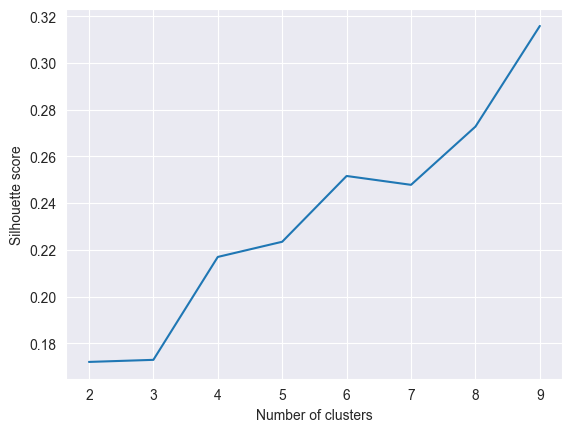


Done!


In [4]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']
personas, features_df, follow = run_simulation_preprocessing(conn, feature_cols=features_cols)

k=2 silhouette=0.1786
k=3 silhouette=0.1891
k=4 silhouette=0.2299
k=5 silhouette=0.2374
k=6 silhouette=0.2665
k=7 silhouette=0.3142
k=8 silhouette=0.3356
k=9 silhouette=0.3472


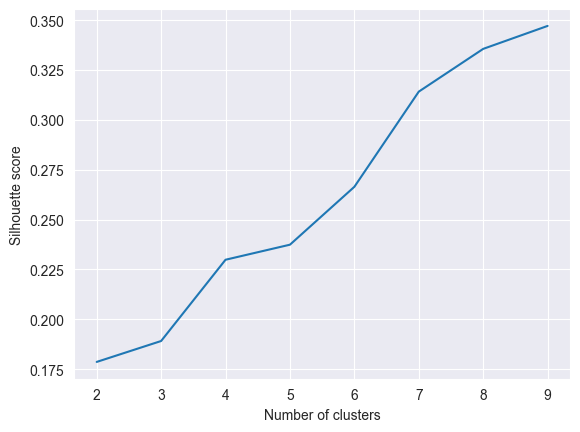

In [5]:
scores = []

for k in range(2, 10):
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(features_df)
    score = silhouette_score(features_df, labels)
    scores.append(score)
    print(f"k={k} silhouette={score:.4f}")

plt.plot(range(2, 10), scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

In [6]:
personas = create_personae(6, personas, features_df)

persona
Persona_1    234
Persona_2    186
Persona_6    158
Persona_3    156
Persona_4    150
Persona_5    116
Name: count, dtype: int64


In [7]:
hier = AgglomerativeClustering(n_clusters=6, linkage='ward')
personas['hier_clusters'] = hier.fit_predict(features_df)
personas['hier_clusters'].value_counts()

hier_clusters
0    263
1    174
3    159
2    152
4    134
5    118
Name: count, dtype: int64

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_df)

In [9]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'kmeans': personas['persona'],
    'hierarchical': personas['hier_clusters'],
    'profession': personas['profession']
})

In [10]:
def plot_pca(plot_df, colour_by=None, title='PCA'):
    # unique interests
    features = plot_df[colour_by].unique()
    # assign colors
    cmap = plt.cm.get_cmap('tab20', len(features))

    plt.figure(figsize=(8, 6))
    for i, colour in enumerate(features):
        subset = plot_df[plot_df[colour_by] == colour]

        plt.scatter(
            subset['PC1'],
            subset['PC2'],
            label=colour,
            alpha=0.7
        )

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

C:\Users\magda\AppData\Local\Temp\ipykernel_21084\2237154511.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(features))


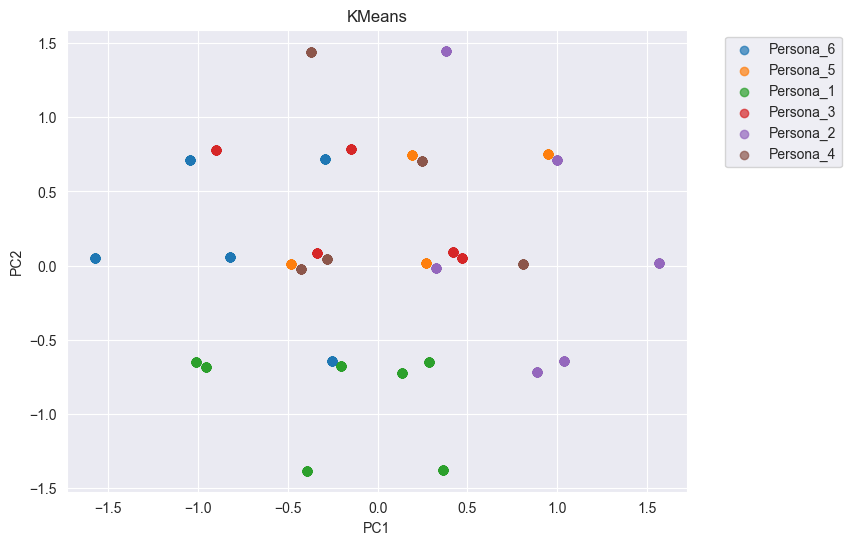

In [11]:
plot_pca(plot_df, colour_by='kmeans', title='KMeans')

C:\Users\magda\AppData\Local\Temp\ipykernel_21084\2237154511.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(features))


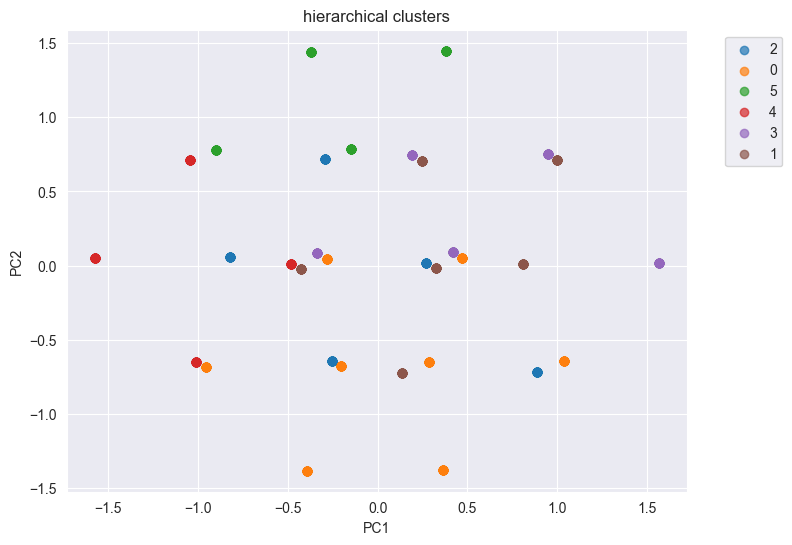

In [12]:
plot_pca(plot_df, colour_by='hierarchical', title='hierarchical clusters')

In [13]:
adjusted_rand_score(personas['persona'], personas['hier_clusters'])

0.284429763698313

In [14]:
print(silhouette_score(features_df, personas['persona']))
print(silhouette_score(features_df, personas['hier_clusters']))

0.25161390581579113
0.2664670875999378


K-means clustering was selected as the primary persona extraction method because it consistently achieved slightly higher silhouette scores on the synthetic (YSocial) dataset and substantially better scores on the Reddit dataset. Additionally, PCA visualizations of Big Five features showed that K-means clusters were more compact and better separated, suggesting clearer personality differentiation between personas.

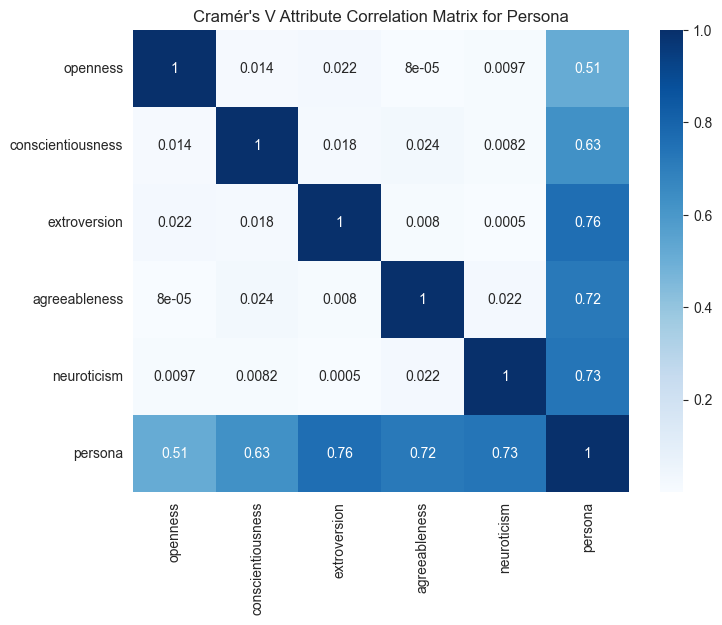

,openness,conscientiousness,extroversion,agreeableness,neuroticism,persona
openness,0.997997,0.013851,0.021539,0.000080,0.009696,0.512198
conscientiousness,0.013851,0.998000,0.017953,0.024008,0.008175,0.627942
extroversion,0.021539,0.017953,0.998000,0.008025,0.000504,0.759289
agreeableness,0.000080,0.024008,0.008025,0.998000,0.021935,0.720576
neuroticism,0.009696,0.008175,0.000504,0.021935,0.997996,0.730847
persona,0.512198,0.627942,0.759289,0.720576,0.730847,1.000000


In [15]:
cramers_v_matrix(personas[features_cols + ['persona']], label='Persona')

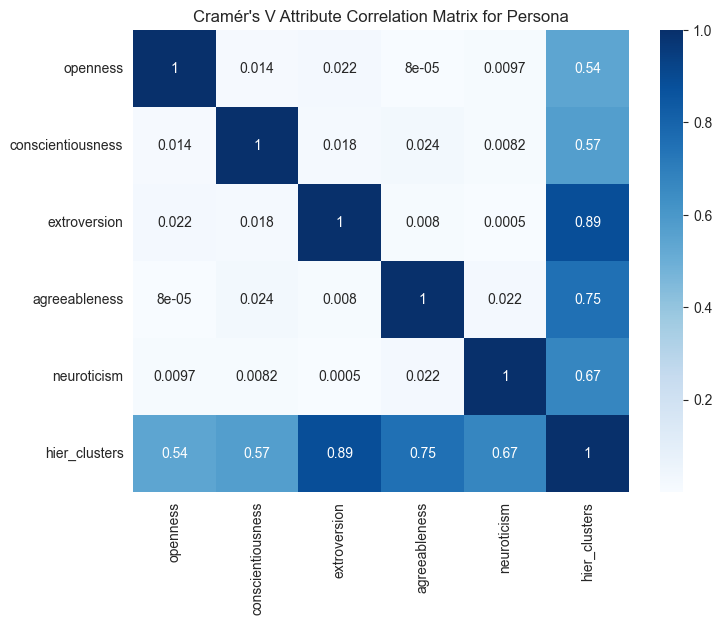

,openness,conscientiousness,extroversion,agreeableness,neuroticism,hier_clusters
openness,0.997997,0.013851,0.021539,0.000080,0.009696,0.541048
conscientiousness,0.013851,0.998000,0.017953,0.024008,0.008175,0.572207
extroversion,0.021539,0.017953,0.998000,0.008025,0.000504,0.886268
agreeableness,0.000080,0.024008,0.008025,0.998000,0.021935,0.750580
neuroticism,0.009696,0.008175,0.000504,0.021935,0.997996,0.669426
hier_clusters,0.541048,0.572207,0.886268,0.750580,0.669426,1.000000


In [16]:
cramers_v_matrix(personas[features_cols + ['hier_clusters']], label='Persona')

KMeans is better.

## Big Five vs. Professions

C:\Users\magda\AppData\Local\Temp\ipykernel_21084\2237154511.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(features))


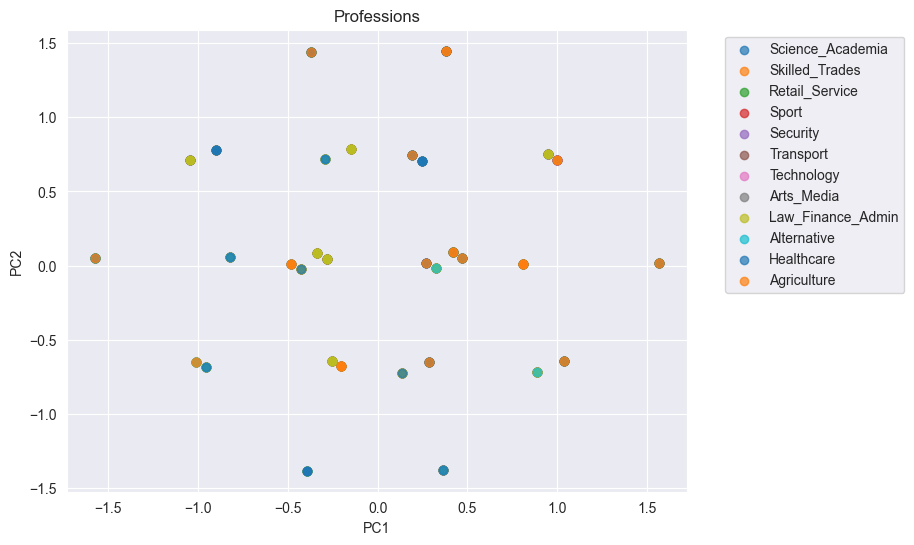

In [17]:
plot_pca(plot_df, colour_by='profession', title='Professions')

It's impossible to plot it since we have only 32 big five traits combinations:(

The synthetic dataset contained only 32 possible Big Five combinations, limiting personality variance and naturally reducing the separability of profession groups in PCA space.

Running Simulation_b1...

Data loading ...

Number of users: 1000
Total actions: 20653
Follow actions: 19661
Unfollow actions: 992
Number of rounds: 51
Number of posts: 194066

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1720
k=3 silhouette=0.1729
k=4 silhouette=0.2169
k=5 silhouette=0.2234
k=6 silhouette=0.2516
k=7 silhouette=0.2478
k=8 silhouette=0.2728
k=9 silhouette=0.3159


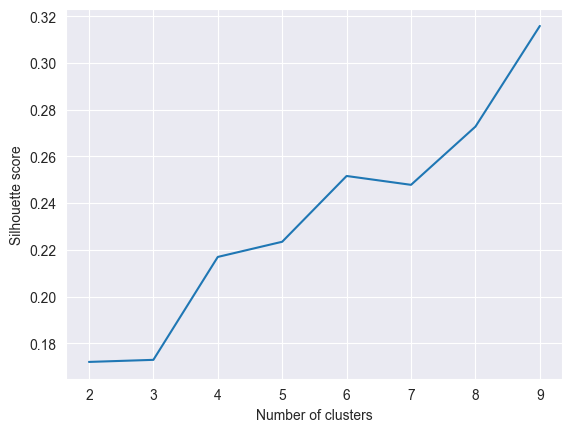


Done!


In [18]:
personaeb1, features_df_b1, followb1 = run_simulation_preprocessing(conn, label='Simulation_b1', feature_cols=features_cols)

Running Simulation_b1...

Persona creation ...

persona
Persona_1    234
Persona_2    186
Persona_6    158
Persona_3    156
Persona_4    150
Persona_5    116
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 1.2307801955218897e-54
conscientiousness: 4.9913527424962484e-83
extroversion: 2.390919307008131e-122
agreeableness: 5.636350347714726e-110
neuroticism: 3.4064796296913e-113


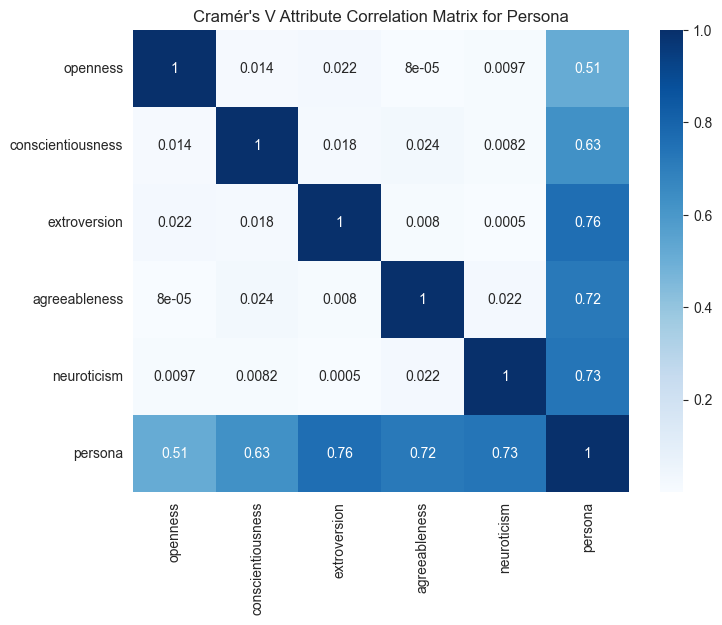

In [19]:
from social_graph.pipeline import *
k_best = 6

description_b1, persona_dict = cluster_persona_and_analyse(personaeb1, features_df_b1, k_best, label='Simulation_b1', feature_cols=features_cols)

In [20]:
global_metrics_b1, summary_b1 = build_graph_and_analyse(followb1, persona_dict, label='Simulation_b1')

Running Simulation_b1...

Graph creation ...

Number of nodes: 983
Number of edges: 18691
Number of connective components: 3
Components sizes: [981, 1, 1]
Number of nodes (LCC): 981
Number of edges (LCC): 18691

Global metrics ...

Mean degree: 38.03
Density: 0.0194
Diameter: 5
Avg. shortest path: 2.510
Modularity score: 0.141
Persona assortativity: 0.0007105317671754317

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.2579
out_degree statistics: p = 0.3330
total_degree statistics: p = 0.3233
betweenness statistics: p = 0.4372
eigenvector statistics: p = 0.3288
pagerank statistics: p = 0.3421
kcore statistics: p = 0.3740


In [21]:
summary_b1

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation
persona,,,,,,,,,,,
Persona_1,228,17.653509,17.732456,35.385965,0.001361,0.000171,0.017503,0.000953,16.311404,0.935092,Simulation_b1
Persona_2,183,17.743169,16.945355,34.688525,0.001499,0.000131,0.017641,0.000969,15.732240,0.950239,Simulation_b1
Persona_3,153,25.052288,24.124183,49.176471,0.002370,0.000276,0.023867,0.001288,18.444444,1.263995,Simulation_b1
Persona_4,149,18.402685,17.912752,36.315436,0.001624,0.000166,0.017731,0.000995,15.657718,0.975863,Simulation_b1
Persona_5,111,18.090090,18.873874,36.963964,0.001461,0.000206,0.018302,0.000974,16.234234,0.955018,Simulation_b1
Persona_6,157,18.063694,19.694268,37.757962,0.001655,0.000120,0.019423,0.000968,16.057325,0.949704,Simulation_b1


In [22]:
description_b1

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.722222,0.277778,0.713675,0.286325,0.846154,0.153846,0.854701,0.145299,0.136752,0.863248
Persona_2,0.543011,0.456989,0.000000,1.000000,0.854839,0.145161,0.333333,0.666667,0.827957,0.172043
Persona_3,0.423077,0.576923,0.365385,0.634615,0.211538,0.788462,0.000000,1.000000,0.000000,1.000000
Persona_4,0.233333,0.766667,1.000000,0.000000,0.773333,0.226667,0.166667,0.833333,0.786667,0.213333
Persona_5,1.000000,0.000000,0.500000,0.500000,0.000000,1.000000,0.482759,0.517241,1.000000,0.000000
Persona_6,0.208861,0.791139,0.417722,0.582278,0.000000,1.000000,1.000000,0.000000,0.373418,0.626582


In [23]:
personas.drop(['hier_clusters'], axis=1, inplace=True)
personas.head()

,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
1,2,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,high school,Persona_6
2,3,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,middle,Skilled_Trades,female,democrat,bachelor,Persona_5
3,4,consistent/cautious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,young,Science_Academia,female,republican,high school,Persona_1
4,5,inventive/curious,efficient/organized,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,high school,Persona_3
5,6,inventive/curious,efficient/organized,solitary/reserved,critical/judgmental,sensitive/nervous,young,Science_Academia,male,centrist,high school,Persona_6


In [24]:
# personas.to_csv('data/exp_set_2/persona_df.csv')